# Filtering Data — PGT-A Dataset

---

**4/10/2026 — N.Q.**

This notebook aims to apply filtering criteria to the dataset to create 3 distinct datasets.
- 1. Single & Double Aneuploidy
- 2. Single Aneuploidy ONLY
- 3. Double Aneuploidy ONLY

This includes re-visualization steps to see outcomes of applied filters.

We selected for the use of Dataset 1: Single & Double Aneuploidy 

---

## 1. Load Libraries & Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Raw dataset is not included in this repo (restricted patient-level data).
# Place ccrm_dataset.csv in a local data/ directory to reproduce this notebook.
original = pd.read_csv("data/ccrm_dataset.csv")
original

,patient_ID,embryo_ID,number_of_embryos,CCS_result,CCS_interpretation,maternal_age,paternal_age,morphology,embryo_age,sex,file_name,path
0,1468,1,5,46XX,Normal,34,*,5AA,5,XX,JTR8W-10-0342-10-BST1_S20_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
1,1468,2,5,46XX,Normal,34,*,3AB,5,XX,JTR8W-10-0342-10-BST2_S21_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
2,1468,3,5,"45XY, -16",Abnormal,34,*,6BB,6,XY,JTR8W-10-0342-10-BST3_S22_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
3,1468,4,5,46XX,Normal,34,*,6BA,6,XX,JTR8W-10-0342-10-BST4_S23_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
4,1468,5,5,"45XX, -22",Abnormal,34,*,3BB,6,XX,JTR8W-10-0342-10-BST5_S24_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
...,...,...,...,...,...,...,...,...,...,...,...,...
40036,7460,4,4,46XX,Normal,32,33,6BB,6,XX,LBVMF-9-2787-9-CHT4_S4_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...
40037,7461,1,4,"45XX, -22",Abnormal,41,41,4AA,5,XX,LBVMF-9-2789-9-CNT1_S20_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...
40038,7461,2,4,46XY,Normal,41,41,4AB,5,XY,LBVMF-9-2789-9-CNT2_S21_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...
40039,7461,3,4,"48XX, +15 +22",Abnormal,41,41,6BB,6,XX,LBVMF-9-2789-9-CNT3_S22_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...


## 2. Helper Functions

Defining reusable functions to avoid repeating the same chromosome-count extraction and aneuploidy rate calculation blocks throughout the notebook.

In [2]:
def get_chromosome_counts(df):
    """Extract leading 2-digit chromosome number from CCS_result for abnormal entries,
    then return a value_counts DataFrame with columns ['chromosome_count', 'total_occurences']."""
    abnorm = df[df["CCS_interpretation"] == "Abnormal"].reset_index(drop=True)
    chrom = abnorm["CCS_result"].str.extract(r"^(\d{2})")
    chrom.columns = ["chromosome_count"]
    chrom["chromosome_count"] = pd.to_numeric(chrom["chromosome_count"], errors="coerce")
    counts = chrom["chromosome_count"].value_counts().reset_index()
    counts.columns = ["chromosome_count", "total_occurences"]
    return counts


def compute_aneuploidy_rate(df, embryo_col="number_of_embryos"):
    """Vectorized per-patient aneuploidy rate calculation.
    Returns one row per patient with maternal_age, embryo count, abnormal count, and rate."""
    df = df.copy()
    df["is_abnormal"] = (df["CCS_interpretation"] == "Abnormal").astype(int)
    summary = df.groupby("patient_ID").agg(
        maternal_age=("maternal_age", "first"),
        embryo_count=(embryo_col, "first"),
        aneuploid_egg_num=("is_abnormal", "sum")
    ).reset_index()
    summary["Aneuploidy_Rate"] = (summary["aneuploid_egg_num"] / summary["embryo_count"]) * 100
    summary["maternal_age"] = summary["maternal_age"].astype(int)
    return summary


def update_embryo_counts(df):
    """Add 'updated_number_of_embryos' column based on per-patient row counts,
    placed directly before CCS_result."""
    df = df.copy()
    df["updated_number_of_embryos"] = df["patient_ID"].map(df["patient_ID"].value_counts())
    cols = list(df.columns)
    cols.remove("updated_number_of_embryos")
    cols.insert(cols.index("CCS_result"), "updated_number_of_embryos")
    return df[cols]


def build_embryo_pt_totals(df, age_range, embryo_range):
    """For each age in age_range, count unique patients by updated_number_of_embryos.
    Returns a combined DataFrame with columns: patient_age, number_of_embryos, pts_w_embryo_count."""
    # Deduplicate to one row per patient, grouped by age
    deduped = df.drop_duplicates(subset="patient_ID")
    result_parts = []
    for a in age_range:
        subset = deduped[deduped["maternal_age"] == a]
        vc = subset["updated_number_of_embryos"].value_counts()
        tbl = vc.reindex(embryo_range, fill_value=0).reset_index()
        tbl.columns = ["number_of_embryos", "pts_w_embryo_count"]
        tbl.insert(0, "patient_age", a)
        result_parts.append(tbl)
    return pd.concat(result_parts, ignore_index=True)


def plot_stacked_bar(full_embryo_pt_totals, title_suffix):
    """Stacked bar chart of patient counts by age and embryo count."""
    pivot = full_embryo_pt_totals.pivot_table(
        index="patient_age", columns="number_of_embryos",
        values="pts_w_embryo_count", fill_value=0
    )
    fig, ax = plt.subplots(figsize=(12, 10))
    x_pos = np.arange(len(pivot.index))
    bottom = np.zeros(len(pivot.index))
    for ec in pivot.columns:
        bars = ax.bar(x_pos, pivot[ec], bottom=bottom, label=f"{ec}")
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + h / 2,
                        str(int(h)), ha="center", va="center", fontsize=8, color="white")
        bottom += pivot[ec].values
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(int(a)) for a in pivot.index], rotation=90)
    ax.set_ylabel("Patient Count")
    ax.set_xlabel("Age Group")
    ax.set_title(f"Number of Patients by Age & Embryo Count {title_suffix}")
    ax.legend(title="Embryo Counts", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_boxplot_aneuploidy(rate_df, title_suffix):
    """Box plot of aneuploidy rate by maternal age."""
    plt.figure(figsize=(30, 6))
    rate_df.boxplot(column="Aneuploidy_Rate", by="maternal_age", grid=False)
    plt.title(f"Patient Age vs Aneuploidy Rate - {title_suffix}")
    plt.suptitle("")
    plt.xlabel("Patient Age")
    plt.ylabel("Aneuploidy Rate")
    plt.xticks(rotation=90, ha="right")
    plt.tight_layout()
    plt.show()


def plot_violin_and_box(df, age_range, title_suffix):
    """Violin and box-whisker plots for embryo count distribution by age."""
    # Build violin data vectorized instead of nested iterrows loops
    deduped = df.drop_duplicates(subset="patient_ID")
    violin_df = deduped[deduped["maternal_age"].isin(age_range)][["maternal_age", "updated_number_of_embryos"]].copy()
    violin_df.columns = ["patient_age", "number_of_embryos"]

    # Violin plot
    plt.figure(figsize=(12, 8))
    sns.violinplot(data=violin_df, x="patient_age", y="number_of_embryos",
                   scale="width", inner="quartile", palette="muted")
    plt.xticks(rotation=90)
    plt.xlabel("Age Group")
    plt.ylabel("Number of Embryos")
    plt.title(f"Distribution of Embryo Counts by Age Group - {title_suffix}")
    plt.tight_layout()
    plt.show()

    # Box-whisker plot
    plt.figure(figsize=(12, 8))
    sns.boxplot(data=violin_df, x="patient_age", y="number_of_embryos",
                palette="muted", showfliers=True)
    plt.xticks(rotation=90)
    plt.xlabel("Age Group")
    plt.ylabel("Number of Embryos")
    plt.title(f"Distribution of Embryo Counts by Age Group - {title_suffix}")
    plt.tight_layout()
    plt.show()

## 3. Create Working DataFrame

Dataset 1's dataframe will be called `ds1_df`.

In [3]:
ds1_df = original.copy()
ds1_df.describe()

,patient_ID,embryo_ID,number_of_embryos,embryo_age
count,40041.000000,40041.000000,40041.000000,40041.000000
mean,4508.448740,5.157539,7.973552,5.631603
std,1720.511115,3.894360,3.642198,0.619504
min,1468.000000,1.000000,1.000000,5.000000
25%,3038.000000,2.000000,5.000000,5.000000
50%,4539.000000,4.000000,7.000000,6.000000
75%,5993.000000,7.000000,10.000000,6.000000
max,7461.000000,52.000000,29.000000,7.000000


### 3.1 Pre-Filter Chromosome Counts

In [4]:
get_chromosome_counts(ds1_df)

,chromosome_count,total_occurences
0,45,6944
1,47,4535
2,46,1501
3,44,978
4,48,727


## 4. Filter Phase 1 — Remove Missing & Extreme Maternal Ages

- Convert `maternal_age` to numeric
- Drop rows with missing maternal age
- Filter out maternal ages ≥ 43

In [5]:
# Convert maternal_age to numeric and drop missing values
ds1_df["maternal_age"] = pd.to_numeric(ds1_df["maternal_age"], errors="coerce")
ds1_df = ds1_df.dropna(subset=["maternal_age"])

print(f"After dropping missing maternal age: {len(ds1_df)} rows, {ds1_df['patient_ID'].nunique()} patients")
ds1_df.describe()

After dropping missing maternal age: 38457 rows, 5779 patients


,patient_ID,embryo_ID,number_of_embryos,maternal_age,embryo_age
count,38457.000000,38457.000000,38457.000000,38457.000000,38457.000000
mean,4508.617235,5.135632,7.928960,34.767091,5.635619
std,1714.719295,3.868067,3.587541,3.897135,0.620303
min,1468.000000,1.000000,1.000000,21.000000,5.000000
25%,3030.000000,2.000000,5.000000,32.000000,5.000000
50%,4546.000000,4.000000,7.000000,35.000000,6.000000
75%,5996.000000,7.000000,10.000000,38.000000,6.000000
max,7461.000000,52.000000,29.000000,53.000000,7.000000


### 4.1 Chromosome Counts & Patient Counts After Dropping Missing Age

In [6]:
get_chromosome_counts(ds1_df)

,chromosome_count,total_occurences
0,45,6735
1,47,4447
2,46,1468
3,44,954
4,48,722


In [7]:
ds1_df["patient_ID"].value_counts().describe()

count    5779.000000
mean        6.654612
std         2.911544
min         1.000000
25%         4.000000
50%         6.000000
75%         8.000000
max        29.000000
Name: count, dtype: float64

### 4.2 Filter Out Maternal Age ≥ 43

In [8]:
ds1_df = ds1_df[ds1_df["maternal_age"] <= 42]

print(f"After age <=42 filter: {len(ds1_df)} rows, {ds1_df['patient_ID'].nunique()} patients")
ds1_df.describe()

After age <=42 filter: 37728 rows, 5664 patients


,patient_ID,embryo_ID,number_of_embryos,maternal_age,embryo_age
count,37728.000000,37728.000000,37728.000000,37728.000000,37728.000000
mean,4503.662691,5.131096,7.933895,34.580020,5.634913
std,1716.055561,3.841368,3.584945,3.680894,0.620364
min,1468.000000,1.000000,1.000000,21.000000,5.000000
25%,3020.000000,2.000000,5.000000,32.000000,5.000000
50%,4538.000000,4.000000,7.000000,35.000000,6.000000
75%,5985.000000,7.000000,10.000000,37.000000,6.000000
max,7461.000000,52.000000,29.000000,42.000000,7.000000


### 4.3 Chromosome Counts & Patient Counts After Age Filter

In [9]:
get_chromosome_counts(ds1_df)

,chromosome_count,total_occurences
0,45,6590
1,47,4357
2,46,1424
3,44,916
4,48,691


In [10]:
ds1_df["patient_ID"].value_counts().describe()

count    5664.000000
mean        6.661017
std         2.911344
min         1.000000
25%         4.000000
50%         6.000000
75%         8.000000
max        29.000000
Name: count, dtype: float64

## 5. Filter Phase 2 — Remove Partial Aneuploidies (p/q Arms)

Remove rows where `CCS_result` contains p-terminal, q-terminal, p-arm, or q-arm deletions.

In [11]:
# Convert CCS columns to string
ds1_df["CCS_interpretation"] = ds1_df["CCS_interpretation"].astype(str)
ds1_df["CCS_result"] = ds1_df["CCS_result"].astype(str)

# Check how many p/q entries exist before removal
pq_mask = ds1_df["CCS_result"].str.contains(r"[pq]", na=False)
print(f"Rows with partial aneuploidies (p/q): {pq_mask.sum()}")

# Filter them out
ds1_df = ds1_df[~pq_mask]
print(f"After p/q removal: {len(ds1_df)} rows")
ds1_df.describe()

Rows with partial aneuploidies (p/q): 55
After p/q removal: 37673 rows


,patient_ID,embryo_ID,number_of_embryos,maternal_age,embryo_age
count,37673.000000,37673.000000,37673.000000,37673.000000,37673.000000
mean,4504.231227,5.131181,7.933480,34.579832,5.635070
std,1715.637221,3.841519,3.584112,3.681359,0.620339
min,1468.000000,1.000000,1.000000,21.000000,5.000000
25%,3022.000000,2.000000,5.000000,32.000000,5.000000
50%,4539.000000,4.000000,7.000000,35.000000,6.000000
75%,5985.000000,7.000000,10.000000,37.000000,6.000000
max,7461.000000,52.000000,29.000000,42.000000,7.000000


### 5.1 Chromosome Counts & Patient Counts After p/q Removal

In [12]:
get_chromosome_counts(ds1_df)

,chromosome_count,total_occurences
0,45,6548
1,47,4346
2,46,1422
3,44,916
4,48,691


In [13]:
ds1_df["patient_ID"].value_counts().describe()

count    5664.000000
mean        6.651306
std         2.907981
min         1.000000
25%         4.000000
50%         6.000000
75%         8.000000
max        29.000000
Name: count, dtype: float64

## 6. Update Per-Cycle Embryo Counts

Now that partial aneuploidies have been removed, per-cycle embryo counts are affected.  
Create `updated_number_of_embryos` based on actual remaining rows per patient.

In [14]:
# Of note: 5548 patients left at this point
ds1_df = update_embryo_counts(ds1_df)
ds1_df

,patient_ID,embryo_ID,number_of_embryos,updated_number_of_embryos,CCS_result,CCS_interpretation,maternal_age,paternal_age,morphology,embryo_age,sex,file_name,path
0,1468,1,5,5,46XX,Normal,34.0,*,5AA,5,XX,JTR8W-10-0342-10-BST1_S20_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
1,1468,2,5,5,46XX,Normal,34.0,*,3AB,5,XX,JTR8W-10-0342-10-BST2_S21_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
2,1468,3,5,5,"45XY, -16",Abnormal,34.0,*,6BB,6,XY,JTR8W-10-0342-10-BST3_S22_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
3,1468,4,5,5,46XX,Normal,34.0,*,6BA,6,XX,JTR8W-10-0342-10-BST4_S23_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
4,1468,5,5,5,"45XX, -22",Abnormal,34.0,*,3BB,6,XX,JTR8W-10-0342-10-BST5_S24_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40036,7460,4,4,4,46XX,Normal,32.0,33,6BB,6,XX,LBVMF-9-2787-9-CHT4_S4_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...
40037,7461,1,4,4,"45XX, -22",Abnormal,41.0,41,4AA,5,XX,LBVMF-9-2789-9-CNT1_S20_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...
40038,7461,2,4,4,46XY,Normal,41.0,41,4AB,5,XY,LBVMF-9-2789-9-CNT2_S21_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...
40039,7461,3,4,4,"48XX, +15 +22",Abnormal,41.0,41,6BB,6,XX,LBVMF-9-2789-9-CNT3_S22_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...


## 7. Branch Datasets 2 & 3

Create copies of `ds1_df` at this stage since DS2 and DS3 share all prior filtering steps.

In [15]:
ds2_df = ds1_df.copy()
ds3_df = ds1_df.copy()

## 8. Dataset 1 — Remove Cycles with < 4 Embryos

In [16]:
ds1_df = ds1_df[ds1_df["updated_number_of_embryos"] >= 4]
print(f"DS1 after >=4 embryo filter: {len(ds1_df)} rows, {ds1_df['patient_ID'].nunique()} patients")

DS1 after >=4 embryo filter: 37558 rows, 5616 patients


### 8.1 DS1 Final Abnormalities & Chromosome Counts

Keep all rows (normal + abnormal) — we have `updated_number_of_embryos` for totals.

In [17]:
ds1_abnormalities_df = ds1_df[ds1_df["CCS_interpretation"] == "Abnormal"].reset_index(drop=True)
print(f"DS1 abnormal embryos: {len(ds1_abnormalities_df)}")
ds1_abnormalities_df.describe()

DS1 abnormal embryos: 13872


,patient_ID,embryo_ID,number_of_embryos,updated_number_of_embryos,maternal_age,embryo_age
count,13872.000000,13872.000000,13872.000000,13872.000000,13872.000000,13872.000000
mean,4495.430219,5.417532,7.692546,7.682526,35.617503,5.759227
std,1779.816220,3.821608,3.471250,3.462872,3.629361,0.642376
min,1468.000000,1.000000,4.000000,4.000000,21.000000,5.000000
25%,2913.000000,3.000000,5.000000,5.000000,33.000000,5.000000
50%,4464.000000,5.000000,7.000000,7.000000,36.000000,6.000000
75%,6154.000000,7.000000,9.000000,9.000000,38.000000,6.000000
max,7461.000000,44.000000,29.000000,29.000000,42.000000,7.000000


In [18]:
get_chromosome_counts(ds1_df)

,chromosome_count,total_occurences
0,45,6526
1,47,4329
2,46,1415
3,44,913
4,48,689


In [19]:
ds1_df["patient_ID"].value_counts().describe()

count    5616.000000
mean        6.687678
std         2.892499
min         4.000000
25%         4.000000
50%         6.000000
75%         8.000000
max        29.000000
Name: count, dtype: float64

In [20]:
ds1_df.to_csv("dataset_ONE.csv", index=False)

---

**Dataset 1 done filtering.** 13,872 abnormal embryos.

37,558 − 13,872 = 23,686 normal embryos

Aneuploidy rate: (13,872 / 37,558) × 100 = 36.93%

---

## 9. Dataset 2 — Single Chromosome Aneuploidy Only

Remove double aneuploidies (CCS_result starting with 44, 46, or 48) from abnormal entries.

In [21]:
print(f"DS2 before filtering: {len(ds2_df)} rows, {ds2_df['patient_ID'].nunique()} patients")

# Remove abnormal entries with double aneuploidy chromosome counts (44, 46, 48)
double_mask = ds2_df["CCS_result"].str.contains(r"(44|46|48)", na=False) & (ds2_df["CCS_interpretation"] == "Abnormal")
ds2_df = ds2_df[~double_mask]

print(f"DS2 after removing doubles: {len(ds2_df)} rows, {ds2_df['patient_ID'].nunique()} patients")

DS2 before filtering: 37673 rows, 5664 patients
DS2 after removing doubles: 34644 rows, 5658 patients


/tmp/ipykernel_2186224/330342090.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  double_mask = ds2_df["CCS_result"].str.contains(r"(44|46|48)", na=False) & (ds2_df["CCS_interpretation"] == "Abnormal")


In [22]:
get_chromosome_counts(ds2_df)

,chromosome_count,total_occurences
0,45,6548
1,47,4346


### 9.1 Update Embryo Counts & Apply ≥ 4 Filter

In [23]:
ds2_df = update_embryo_counts(ds2_df)
ds2_df = ds2_df[ds2_df["updated_number_of_embryos"] >= 4]

print(f"DS2 after >=4 embryo filter: {len(ds2_df)} rows, {ds2_df['patient_ID'].nunique()} patients")
ds2_df.describe()

DS2 after >=4 embryo filter: 32983 rows, 5032 patients


,patient_ID,embryo_ID,number_of_embryos,updated_number_of_embryos,maternal_age,embryo_age
count,32983.000000,32983.000000,32983.000000,32983.000000,32983.000000,32983.000000
mean,4503.477125,5.215141,8.173665,7.738987,34.258345,5.613286
std,1694.176813,3.902305,3.588530,3.463637,3.594078,0.614750
min,1468.000000,1.000000,4.000000,4.000000,21.000000,5.000000
25%,3052.000000,2.000000,5.000000,5.000000,32.000000,5.000000
50%,4556.000000,4.000000,7.000000,7.000000,34.000000,6.000000
75%,5934.000000,7.000000,10.000000,10.000000,37.000000,6.000000
max,7460.000000,52.000000,29.000000,28.000000,42.000000,7.000000


In [24]:
ds2_abnormalities_df = ds2_df[ds2_df["CCS_interpretation"] == "Abnormal"].reset_index(drop=True)
print(f"DS2 abnormal embryos: {len(ds2_abnormalities_df)}")
ds2_abnormalities_df.describe()

DS2 abnormal embryos: 10175


,patient_ID,embryo_ID,number_of_embryos,updated_number_of_embryos,maternal_age,embryo_age
count,10175.000000,10175.000000,10175.000000,10175.000000,10175.000000,10175.000000
mean,4485.315872,5.567568,8.015921,7.492776,35.160590,5.735332
std,1749.818566,3.933111,3.513145,3.355035,3.555972,0.642527
min,1468.000000,1.000000,4.000000,4.000000,21.000000,5.000000
25%,2930.500000,3.000000,5.000000,5.000000,33.000000,5.000000
50%,4490.000000,5.000000,7.000000,7.000000,35.000000,6.000000
75%,6071.500000,7.000000,10.000000,9.000000,38.000000,6.000000
max,7460.000000,44.000000,29.000000,28.000000,42.000000,7.000000


In [25]:
get_chromosome_counts(ds2_df)

,chromosome_count,total_occurences
0,45,6161
1,47,4014


In [26]:
ds2_df.to_csv("dataset_TWO.csv", index=False)

---

**Dataset 2 done filtering.** 10,608 abnormal embryos.

34,017 − 10,608 = 23,049 normal embryos

Aneuploidy rate = (10,608 / 34,107) × 100 = 31.102%

---

## 10. Dataset 3 — Double Chromosome Aneuploidy Only

Remove single aneuploidies (CCS_result starting with 45 or 47) from abnormal entries.

In [27]:
print(f"DS3 before filtering: {len(ds3_df)} rows, {ds3_df['patient_ID'].nunique()} patients")

# Remove abnormal entries with single aneuploidy chromosome counts (45, 47)
single_mask = ds3_df["CCS_result"].str.contains(r"(45|47)", na=False) & (ds3_df["CCS_interpretation"] == "Abnormal")
ds3_df = ds3_df[~single_mask]

print(f"DS3 after removing singles: {len(ds3_df)} rows, {ds3_df['patient_ID'].nunique()} patients")

DS3 before filtering: 37673 rows, 5664 patients
DS3 after removing singles: 26779 rows, 5635 patients


/tmp/ipykernel_2186224/1578098376.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  single_mask = ds3_df["CCS_result"].str.contains(r"(45|47)", na=False) & (ds3_df["CCS_interpretation"] == "Abnormal")


In [28]:
get_chromosome_counts(ds3_df)

,chromosome_count,total_occurences
0,46,1422
1,44,916
2,48,691


### 10.1 Update Embryo Counts & Apply ≥ 4 Filter

In [29]:
ds3_df = update_embryo_counts(ds3_df)
ds3_df = ds3_df[ds3_df["updated_number_of_embryos"] >= 4]

print(f"DS3 after >=4 embryo filter: {len(ds3_df)} rows, {ds3_df['patient_ID'].nunique()} patients")
ds3_df.describe()

DS3 after >=4 embryo filter: 22030 rows, 3697 patients


,patient_ID,embryo_ID,number_of_embryos,updated_number_of_embryos,maternal_age,embryo_age
count,22030.000000,22030.000000,22030.000000,22030.000000,22030.000000,22030.000000
mean,4528.634725,5.396005,8.699591,6.808443,33.882978,5.572084
std,1675.339333,3.976149,3.575835,2.770388,3.617626,0.598811
min,1469.000000,1.000000,4.000000,4.000000,21.000000,5.000000
25%,3160.000000,2.000000,6.000000,5.000000,31.000000,5.000000
50%,4593.000000,5.000000,8.000000,6.000000,34.000000,6.000000
75%,5897.000000,7.000000,11.000000,8.000000,36.000000,6.000000
max,7457.000000,52.000000,29.000000,24.000000,42.000000,7.000000


In [30]:
ds3_abnormalities_df = ds3_df[ds3_df["CCS_interpretation"] == "Abnormal"].reset_index(drop=True)
print(f"DS3 abnormal embryos: {len(ds3_abnormalities_df)}")
ds3_abnormalities_df.describe()

DS3 abnormal embryos: 2199


,patient_ID,embryo_ID,number_of_embryos,updated_number_of_embryos,maternal_age,embryo_age
count,2199.000000,2199.000000,2199.000000,2199.000000,2199.000000,2199.000000
mean,4514.602092,6.049113,8.313324,6.284220,36.084584,5.806730
std,1831.296362,3.815627,3.288323,2.417084,3.614012,0.635921
min,1469.000000,1.000000,4.000000,4.000000,23.000000,5.000000
25%,2874.000000,3.000000,6.000000,4.000000,34.000000,5.000000
50%,4402.000000,5.000000,8.000000,6.000000,37.000000,6.000000
75%,6327.000000,8.000000,10.000000,7.000000,39.000000,6.000000
max,7457.000000,31.000000,29.000000,24.000000,42.000000,7.000000


In [31]:
get_chromosome_counts(ds3_df)

,chromosome_count,total_occurences
0,46,1030
1,44,665
2,48,504


In [32]:
ds3_df.to_csv("dataset_THREE.csv", index=False)

---

**Dataset 3 done filtering.** 2,123 abnormal embryos.

21,743 total embryos

Aneuploidy rate = 9.764%

---

## 11. Per-Patient Aneuploidy Rate — All Datasets

Compute aneuploidy rate per patient using vectorized `groupby` + `agg` instead of  
looping through patient ID ranges with `iterrows`.

In [33]:
# Old approach (used in all 3 datasets):
# for j in range(1468, 7462):
#     tempdf = ds1_df.loc[ds1_df["patient_ID"] == j]
#     ...
#     for index, row in tempdf.iterrows():
#         if row["CCS_interpretation"] == "Abnormal":
#             abnormalCounter += 1
#     aneuploidyRate = (abnormalCounter / totals) * 100

# Vectorized for all three datasets:
DS1_AneuploidyRate_df = compute_aneuploidy_rate(ds1_df)
DS2_AneuploidyRate_df = compute_aneuploidy_rate(ds2_df)
DS3_AneuploidyRate_df = compute_aneuploidy_rate(ds3_df)

DS1_AneuploidyRate_df

,patient_ID,maternal_age,embryo_count,aneuploid_egg_num,Aneuploidy_Rate
0,1468,34,5,2,40.000000
1,1469,27,14,7,50.000000
2,1471,32,4,2,50.000000
3,1472,39,4,3,75.000000
4,1473,41,4,1,25.000000
...,...,...,...,...,...
5611,7456,39,5,4,80.000000
5612,7457,33,7,3,42.857143
5613,7458,37,4,3,75.000000
5614,7460,32,4,1,25.000000


## 12. GLM Preparation (Dataset 1)

This step is necessary for the GLM regression analysis — merging phenotype, PCA, and genotype data.

Columns needed: **patient_id, embryo_count, aneuploid_egg_num, mean_maternal_age**

In [34]:
# The vectorized compute_aneuploidy_rate already produces what we need
DS1_GLM_df = compute_aneuploidy_rate(ds1_df, embryo_col="updated_number_of_embryos")

# Select and rename columns to match GLM expected format
DS1_GLM_df = DS1_GLM_df[["patient_ID", "embryo_count", "aneuploid_egg_num", "maternal_age"]].copy()
DS1_GLM_df["aneuploid_egg_num"] = DS1_GLM_df["aneuploid_egg_num"].astype(int)
DS1_GLM_df = DS1_GLM_df.rename(columns={
    "embryo_count": "embryo_count",
    "maternal_age": "mean_maternal_age"
})

DS1_GLM_df.to_csv("DS1_GLM_df.csv", index=False)
DS1_GLM_df

,patient_ID,embryo_count,aneuploid_egg_num,mean_maternal_age
0,1468,5,2,34
1,1469,14,7,27
2,1471,4,2,32
3,1472,4,3,39
4,1473,4,1,41
...,...,...,...,...
5611,7456,5,4,39
5612,7457,7,3,33
5613,7458,4,3,37
5614,7460,4,1,32


---

**END SECTION FOR GLM**

---

## 13. Age vs. Aneuploidy Rate — Subsets for Plotting

In [35]:
DS1_patientAge_vs_AneuploidyRate_df = DS1_AneuploidyRate_df[["maternal_age", "Aneuploidy_Rate"]]
DS2_patientAge_vs_AneuploidyRate_df = DS2_AneuploidyRate_df[["maternal_age", "Aneuploidy_Rate"]]
DS3_patientAge_vs_AneuploidyRate_df = DS3_AneuploidyRate_df[["maternal_age", "Aneuploidy_Rate"]]

## 14. Aneuploidy Rate Box Plots

### Dataset 1

<Figure size 3000x600 with 0 Axes>

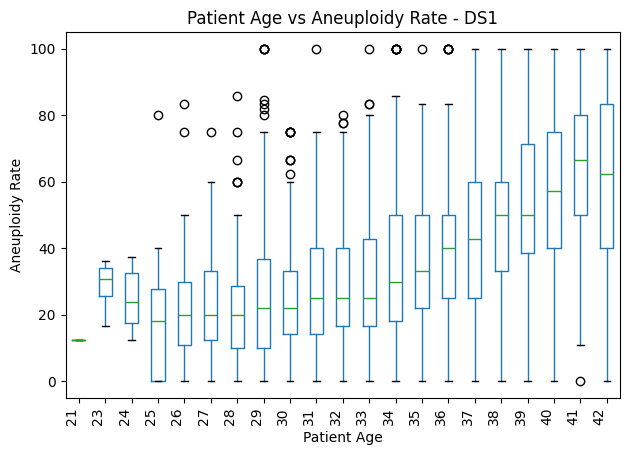

In [36]:
plot_boxplot_aneuploidy(DS1_patientAge_vs_AneuploidyRate_df, "DS1")

### Dataset 2

<Figure size 3000x600 with 0 Axes>

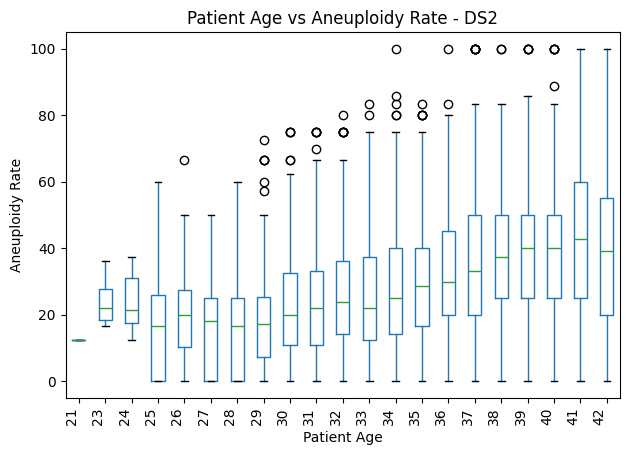

In [37]:
plot_boxplot_aneuploidy(DS2_patientAge_vs_AneuploidyRate_df, "DS2")

### Dataset 3

<Figure size 3000x600 with 0 Axes>

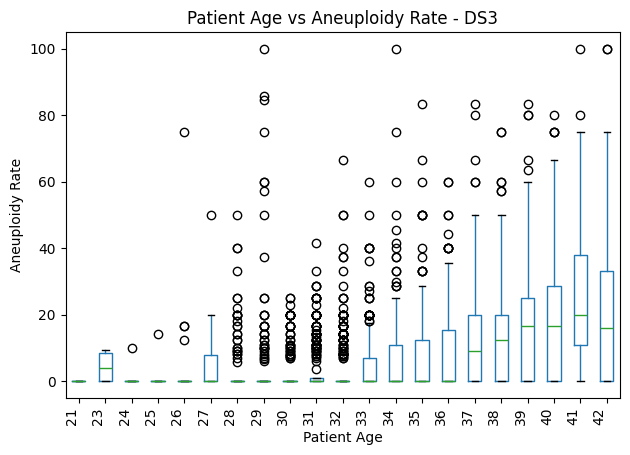

In [38]:
plot_boxplot_aneuploidy(DS3_patientAge_vs_AneuploidyRate_df, "DS3")

## 15. Embryo Counts by Age — Stacked Bar Charts

Build embryo-count × patient-count tables and stacked bar charts for each dataset.

### Dataset 1

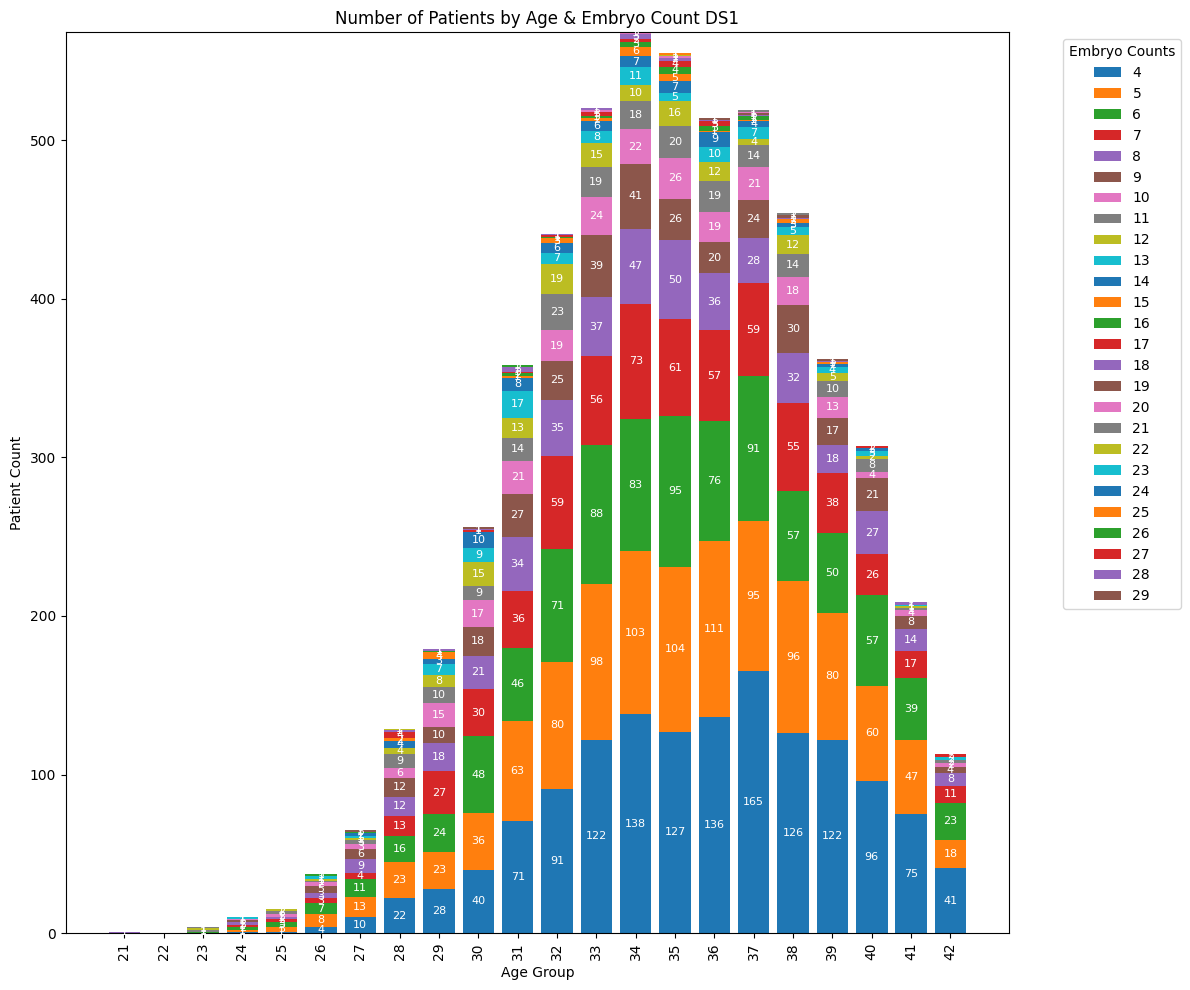

In [39]:
DS1_fullEmbryoPtTotals = build_embryo_pt_totals(ds1_df, range(21, 43), range(4, 30))
plot_stacked_bar(DS1_fullEmbryoPtTotals, "DS1")

#### Dominant Age Group (32–38) — DS1

In [40]:
ds1_dominant_count = ds1_df[ds1_df["maternal_age"].between(32, 38)]["patient_ID"].nunique()
ds1_total_count = ds1_df["patient_ID"].nunique()
print(f"Dominant age group (32-38): {ds1_dominant_count} / {ds1_total_count} patients "
      f"({ds1_dominant_count / ds1_total_count * 100:.1f}%)")

Dominant age group (32-38): 3571 / 5616 patients (63.6%)


#### Violin & Box Plots — DS1

/tmp/ipykernel_2186224/3096571934.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=violin_df, x="patient_age", y="number_of_embryos",
/tmp/ipykernel_2186224/3096571934.py:105: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=violin_df, x="patient_age", y="number_of_embryos",


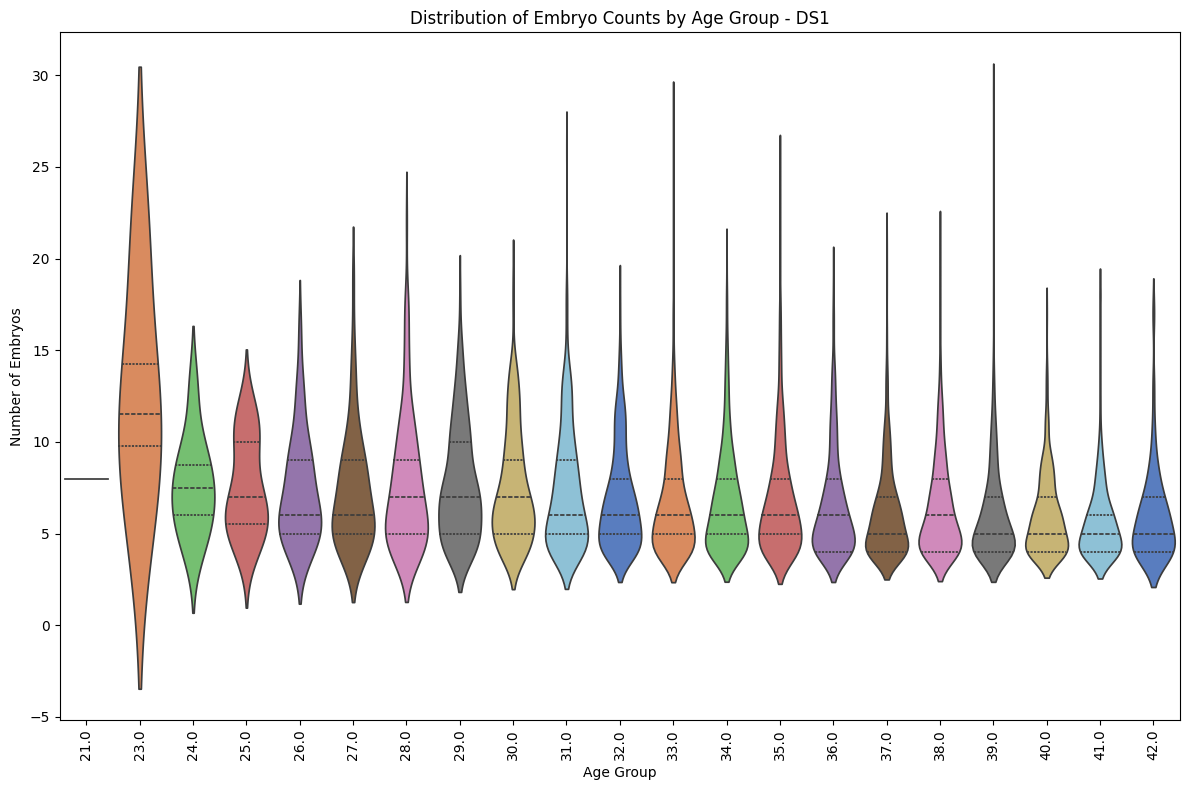

/tmp/ipykernel_2186224/3096571934.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=violin_df, x="patient_age", y="number_of_embryos",


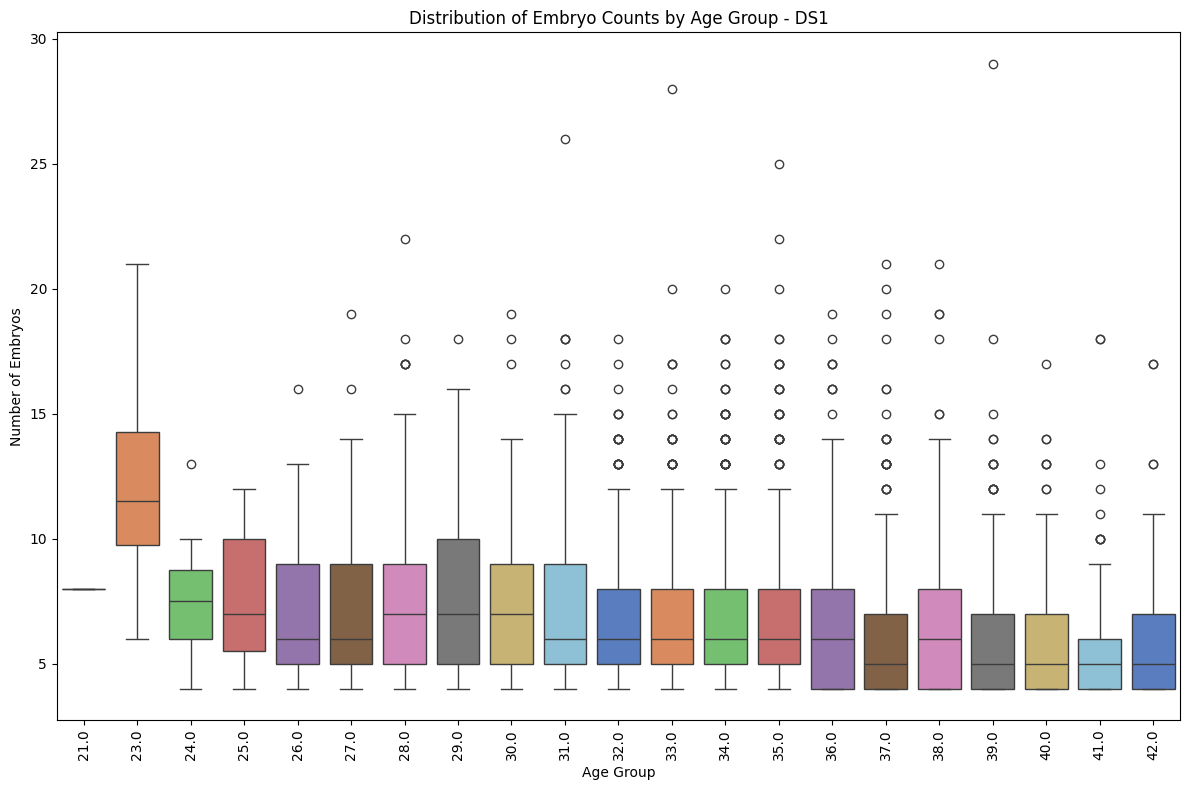

In [41]:
plot_violin_and_box(ds1_df, range(21, 43), "DS1")

### Dataset 2

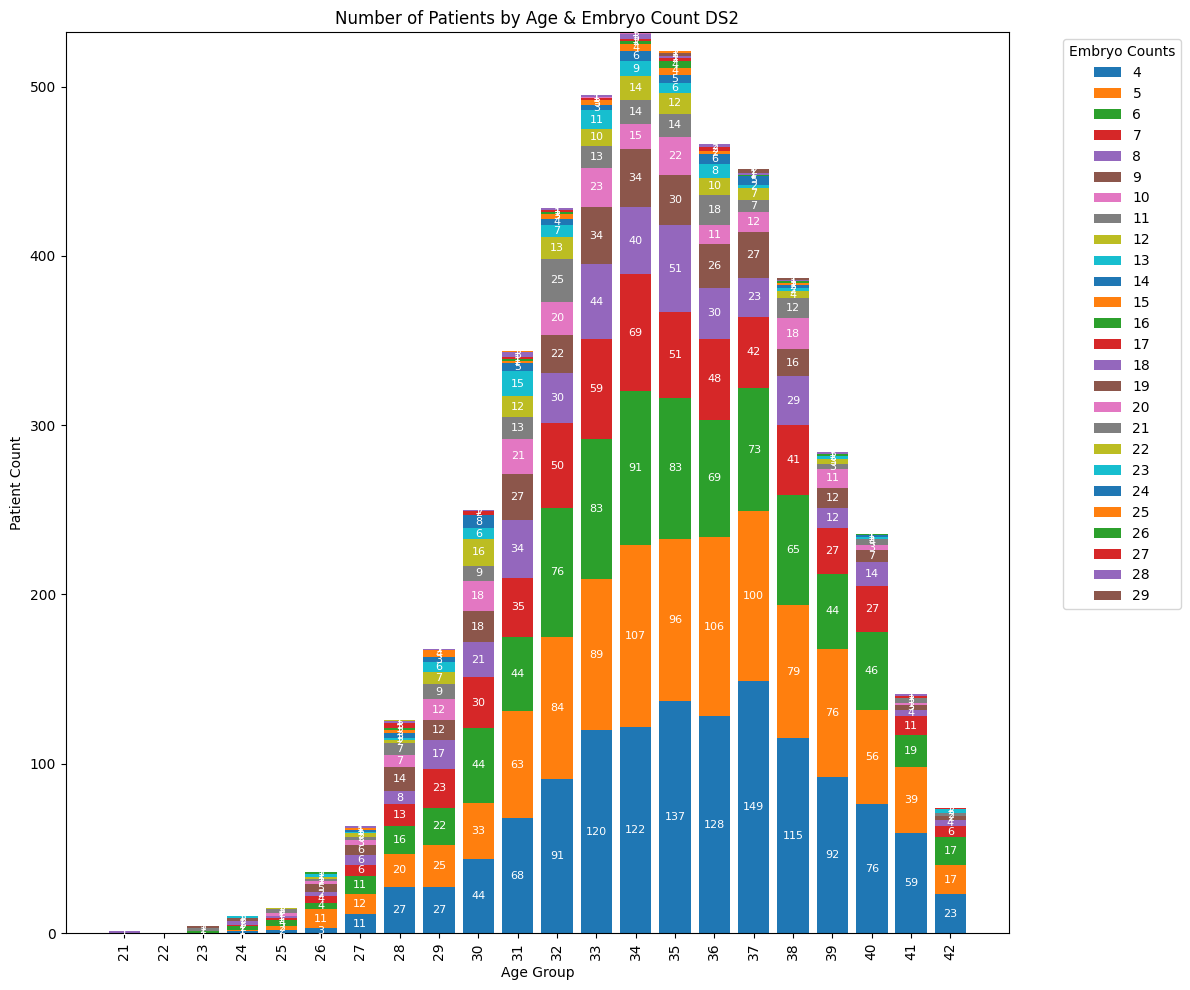

In [42]:
DS2_fullEmbryoPtTotals = build_embryo_pt_totals(ds2_df, range(21, 43), range(4, 30))
plot_stacked_bar(DS2_fullEmbryoPtTotals, "DS2")

#### Dominant Age Group (32–38) — DS2

In [43]:
ds2_dominant_count = ds2_df[ds2_df["maternal_age"].between(32, 38)]["patient_ID"].nunique()
ds2_total_count = ds2_df["patient_ID"].nunique()
print(f"Dominant age group (32-38): {ds2_dominant_count} / {ds2_total_count} patients "
      f"({ds2_dominant_count / ds2_total_count * 100:.1f}%)")

Dominant age group (32-38): 3280 / 5032 patients (65.2%)


#### Violin & Box Plots — DS2

/tmp/ipykernel_2186224/3096571934.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=violin_df, x="patient_age", y="number_of_embryos",
/tmp/ipykernel_2186224/3096571934.py:105: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=violin_df, x="patient_age", y="number_of_embryos",


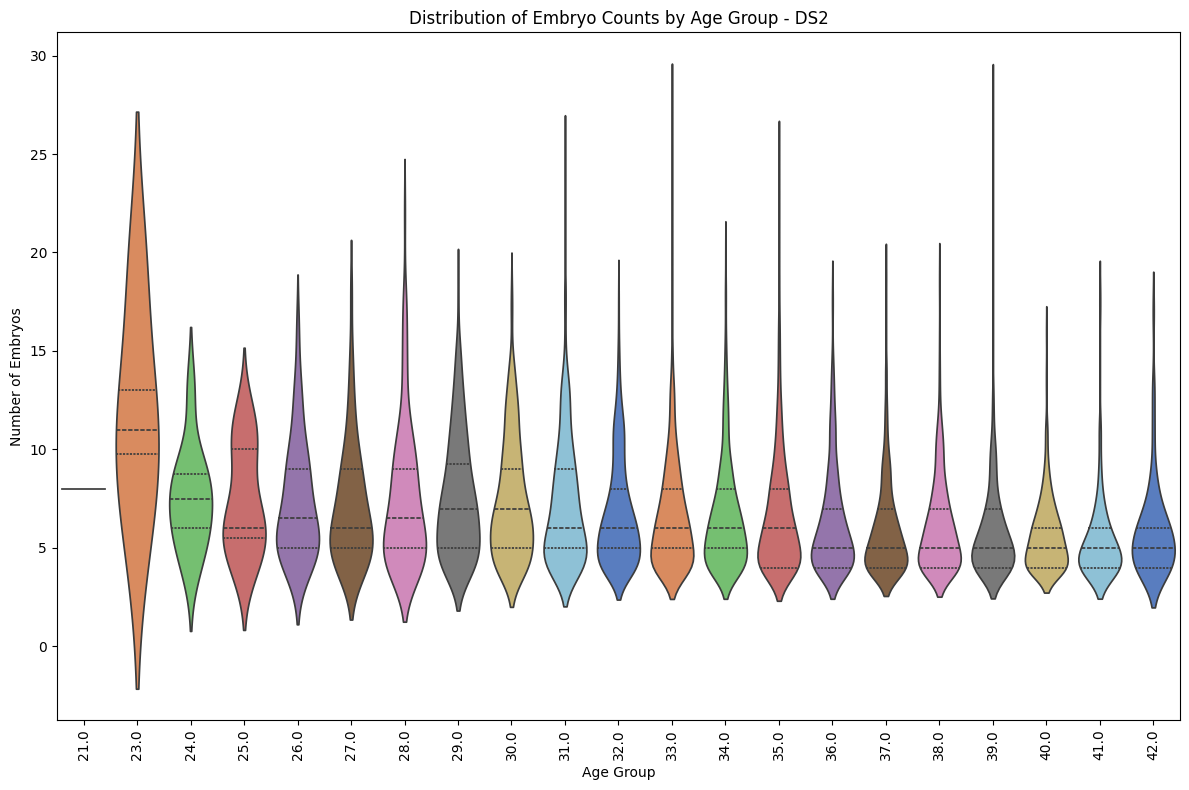

/tmp/ipykernel_2186224/3096571934.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=violin_df, x="patient_age", y="number_of_embryos",


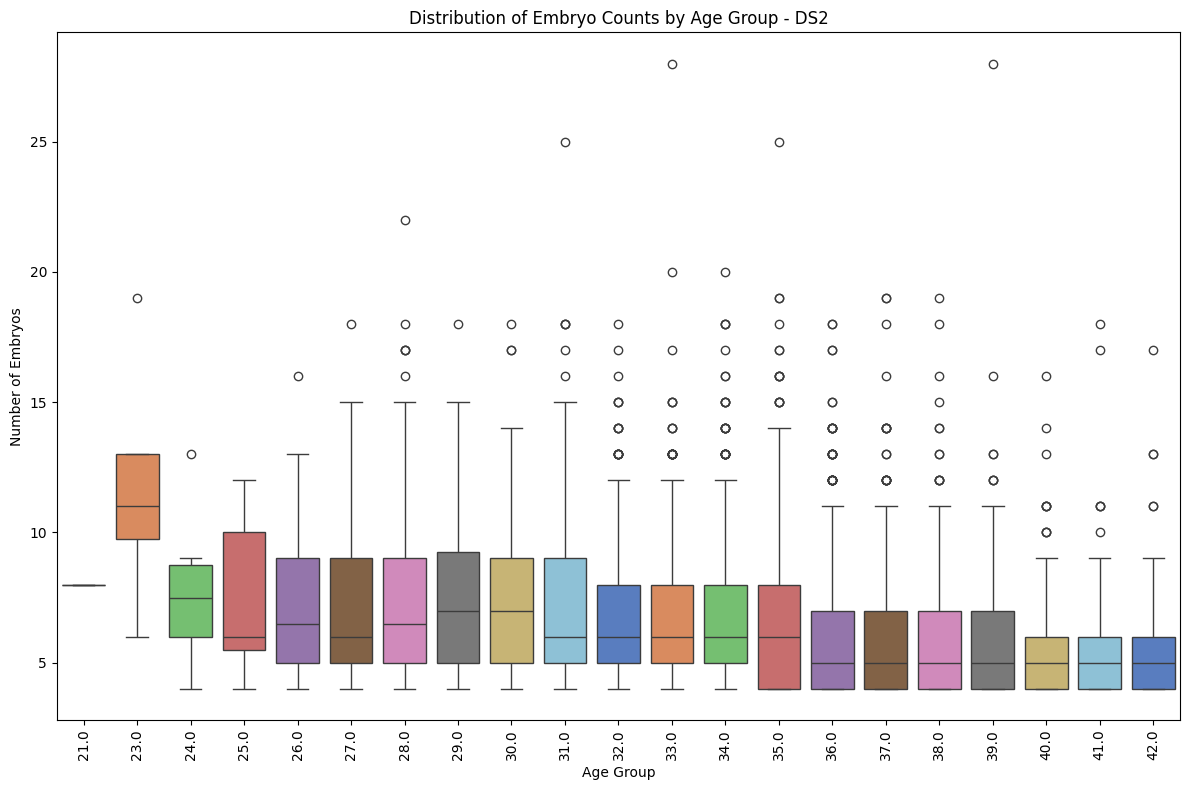

In [44]:
plot_violin_and_box(ds2_df, range(21, 43), "DS2")

### Dataset 3

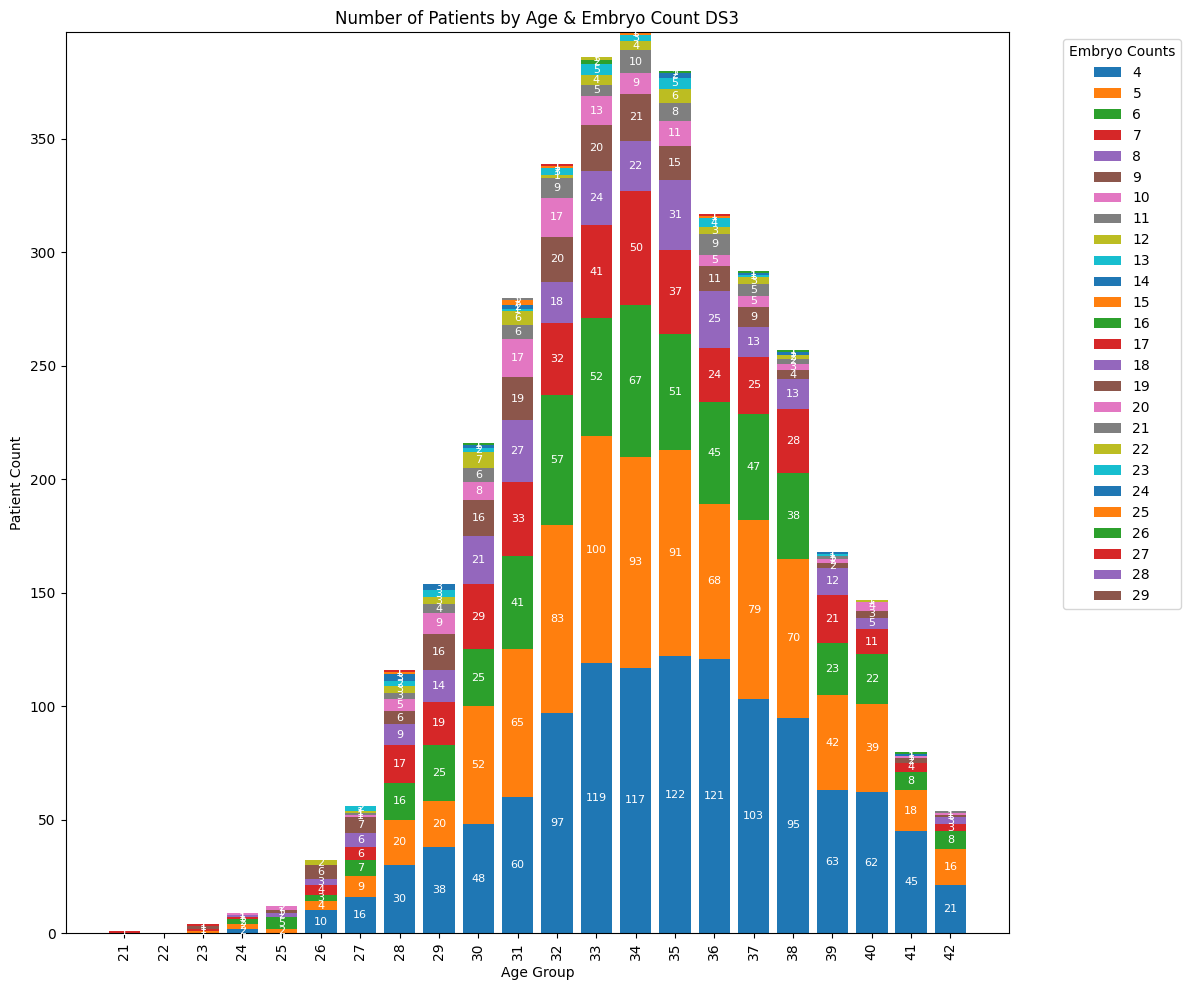

In [45]:
DS3_fullEmbryoPtTotals = build_embryo_pt_totals(ds3_df, range(21, 43), range(4, 30))
plot_stacked_bar(DS3_fullEmbryoPtTotals, "DS3")

#### Dominant Age Group (32–36) — DS3

In [46]:
ds3_dominant_count = ds3_df[ds3_df["maternal_age"].between(32, 36)]["patient_ID"].nunique()
ds3_total_count = ds3_df["patient_ID"].nunique()
print(f"Dominant age group (32-36): {ds3_dominant_count} / {ds3_total_count} patients "
      f"({ds3_dominant_count / ds3_total_count * 100:.1f}%)")

Dominant age group (32-36): 1819 / 3697 patients (49.2%)


#### Violin & Box Plots — DS3

/tmp/ipykernel_2186224/3096571934.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=violin_df, x="patient_age", y="number_of_embryos",
/tmp/ipykernel_2186224/3096571934.py:105: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=violin_df, x="patient_age", y="number_of_embryos",


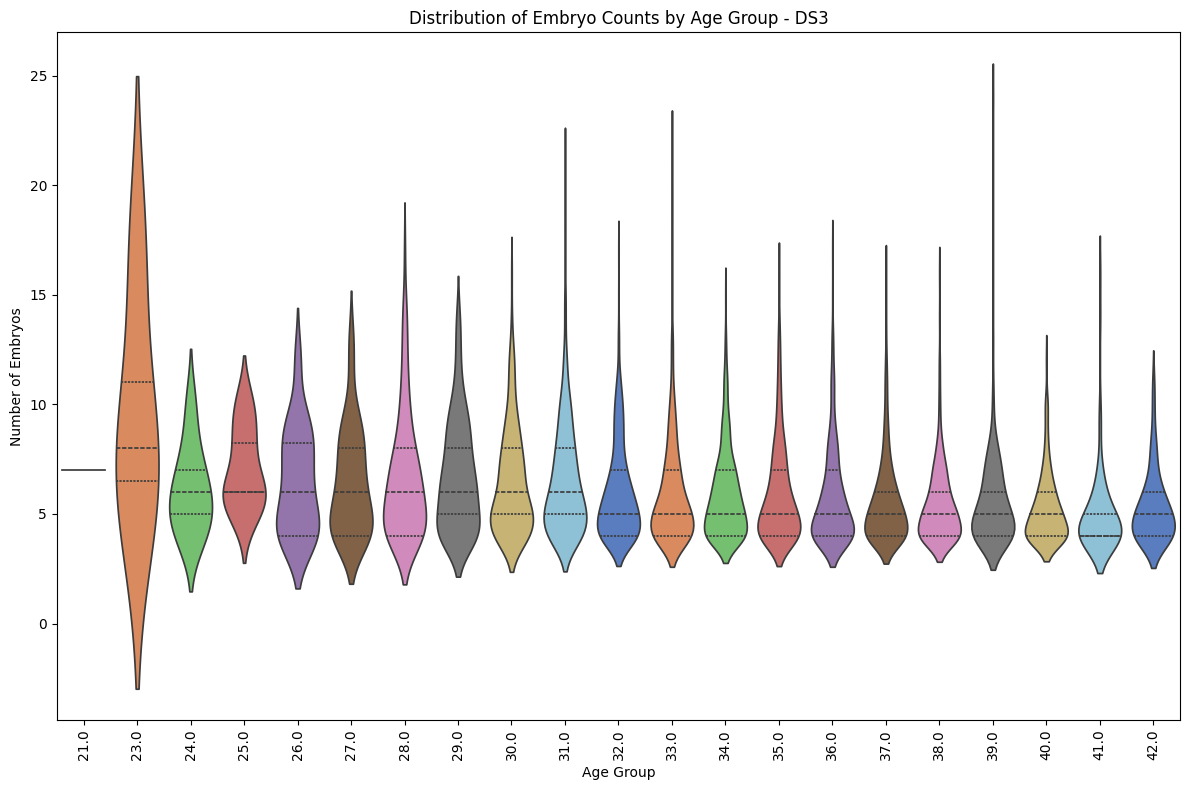

/tmp/ipykernel_2186224/3096571934.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=violin_df, x="patient_age", y="number_of_embryos",


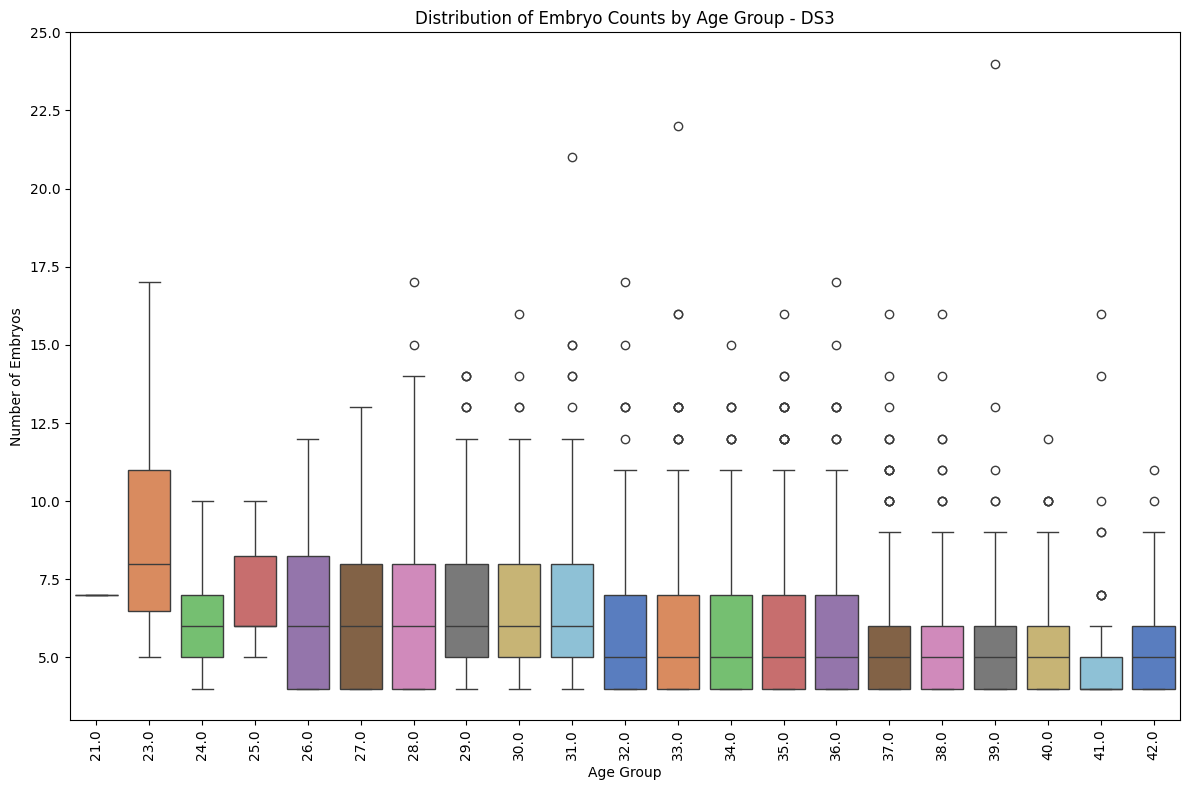

In [47]:
plot_violin_and_box(ds3_df, range(21, 43), "DS3")